(user_guide_optimization_aco)=

# Ant Colony Optimization (ACO)

📖 {ref}`Optimization API Reference <api_optimization_ACO>`

**Ant Colony Optimization (ACO)** is a metaheuristic inspired by how real ant colonies find short paths between their nest and a food source. A single ant explores more or less at random, but it deposits a chemical trail (pheromone) as it moves. Ants that happen to take a shorter path complete more round trips per unit time, so their pheromone accumulates faster.

Because ants are more likely to follow trails with stronger pheromone, short paths get reinforced, and over many iterations the colony's collective behavior converges toward good paths -- without any single ant "knowing" the best route.

Algorithmically, every ACO variant repeats the same three-step loop:

1. **Construct solutions** -- each of `nAnts` ants builds a candidate solution, using the current pheromone information to bias (but not fully determine) its choices.
2. **Evaluate** the constructed solutions with the objective function.
3. **Update the pheromones** -- existing pheromone evaporates a little (so the colony can forget bad decisions and keep exploring), and the ants that constructed good solutions deposit new pheromone that reinforces the choices they made.

This loop is implemented once, in {py:class}`~sigmaepsilon.math.optimize.aco.AntColonyOptimization`, which also takes care of bookkeeping shared by all variants: tracking the best solution found so far (the *champion*), counting iterations and function evaluations, and stopping either after `maxiter` iterations or once the champion hasn't improved for `maxage` iterations in a row (stagnation). What differs between problem types is *what* a "solution" is and *how* pheromones are represented, so the base class leaves `construct_solutions` and `update_pheromones` abstract, and two concrete subclasses fill them in:

* {py:class}`~sigmaepsilon.math.optimize.aco.ContinuousAntColonyOptimization` (**ACOR**), for
  unconstrained-shape, box-constrained problems over continuous real-valued variables.
* {py:class}`~sigmaepsilon.math.optimize.aco.CombinatorialAntColonyOptimization` (**Ant System**),
  for permutation problems defined over a distance matrix, the classic example being the
  Traveling Salesman Problem (TSP).

## When to use it (and when not to)

ACO is a good fit when:

* the search space is not smooth enough (or not known in closed form) for gradient-based
  methods, so you need a derivative-free, population-based search, and
* the problem has either a natural continuous, box-constrained structure (use ACOR), or a natural *sequencing / permutation* structure with a notion of pairwise cost between elements (use the combinatorial variant) -- routing, scheduling, assignment-like problems.

It is usually **not** the right tool when:

* the objective is linear (or convex) and constraints are linear -- use [Linear Programming](lp.ipynb) (`linprog`/HIGHS), which will find the *exact* optimum, faster and deterministically.
* the problem is smooth and gradient information is available -- a gradient-based nonlinear solver will typically converge faster and more reliably than any metaheuristic.
* you need a real-valued box-constrained search but don't have a combinatorial structure -- the
  library's [genetic algorithms](bga.ipynb) solve the same class of problems as ACOR and are worth comparing against; neither is strictly better; ACOR tends to do well when good solutions cluster together in a few regions, while GAs with crossover can be better at
  combining unrelated partial solutions.

As with any metaheuristic, ACO gives you *no optimality guarantee* -- only a good solution found within a finite budget of iterations and function evaluations.

## Continuous ACO (ACOR)

`ContinuousAntColonyOptimization` implements ACOR (Socha & Dorigo, 2008). Instead of a
pheromone matrix, it keeps a **solution archive**: the `archive_size` best solutions found so
far, sorted by fitness. In each iteration:

* every ant picks one archive member as a "seed", with better-ranked members picked with higher
  probability (the `q` parameter controls how strongly the choice is biased toward the best
  solutions -- small `q` means an almost greedy pick, large `q` gives near-uniform choice among
  archive members),
* the ant then samples a new candidate solution from a Gaussian centered on that seed, with a
  per-dimension standard deviation derived from how spread out the archive is along that
  dimension, scaled by `xi` (larger `xi` means wider sampling, i.e. more exploration),
* the newly-constructed solutions are merged into the archive together with the previous
  members, and only the `archive_size` best survive -- this *is* the pheromone update: the
  archive itself plays the role of the pheromone trail, since it is what future iterations
  sample around.

So the archive both memorizes the current best-known solutions and, through its spread,
controls how far new solutions can stray from them -- shrinking automatically as the population
converges.

In [1]:
from sigmaepsilon.math.optimize import ContinuousAntColonyOptimization as ACOR


def rosenbrock(x, a=1.0, b=100.0):
    return (a - x[0]) ** 2 + b * (x[1] - x[0] ** 2) ** 2


ranges = [[-5, 5], [-5, 5]]  # box constraints for x0 and x1

acor = ACOR(
    rosenbrock,
    ranges,
    archive_size=30,
    nAnts=20,
    q=0.3,
    xi=0.7,
    maxiter=200,
    minimize=True,
    seed=42,
)
result = acor.solve()
result.phenotype, result.fitness

([0.9406787636842728, 0.8836126174149843], 0.0036787582098673152)

The Rosenbrock function has its minimum at $(1, 1)$ with value $0$; the result above should
land close to it. `solve` returns the champion as an
{py:class}`~sigmaepsilon.math.optimize.aco.AntSolution` (with `.phenotype` and `.fitness`); the
same information is also available afterwards via `acor.best_phenotype()` /
`acor.best_candidate()`, and `acor.state` exposes the run's iteration/evaluation counters.

In [2]:
acor.state.n_iter, acor.state.n_fev, acor.state.success

(23, 490, True)

If your objective function can evaluate a whole batch of candidates at once (e.g. vectorized
NumPy code), pass `vectorized=True` so all `nAnts` candidates of an iteration are evaluated in a
single call instead of one Python-level call per ant; for expensive, non-vectorizable objectives
you can instead parallelize across ants with `n_jobs` (`-1` uses all available CPUs).

## Combinatorial ACO (Ant System / TSP)

`CombinatorialAntColonyOptimization` implements the original Ant System algorithm (Dorigo et
al., 1996) for problems defined over a symmetric `distance_matrix`, most naturally the
Traveling Salesman Problem: visit every node exactly once and return to the start, minimizing
total travel distance.

Here the pheromone really is a matrix $\tau_{ij}$, one entry per directed edge between nodes,
initialized to `tau_init`. Alongside it, a fixed heuristic desirability $\eta_{ij} = 1 /
d_{ij}$ favors short edges regardless of pheromone. Each ant builds a full tour node by node,
starting from a random node and, at every step, picking the next unvisited node $j$ from the
current node $i$ with probability proportional to

$$
\tau_{ij}^{\alpha} \cdot \eta_{ij}^{\beta}
$$

so `alpha` controls how strongly the ants trust accumulated pheromone (experience) and `beta`
controls how strongly they trust the raw distance (greediness). After all ants have built a
tour, pheromone evaporates everywhere by a factor `(1 - rho)`, and every ant deposits
`Q / tour_length` on each edge of its tour -- so shorter tours reinforce their edges more
strongly, and edges nobody uses keep fading away.

In [3]:
import numpy as np
from sigmaepsilon.math.optimize import CombinatorialAntColonyOptimization as AntSystem

rng = np.random.default_rng(0)
n_cities = 15
coords = rng.uniform(0, 100, size=(n_cities, 2))
distance_matrix = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)


def tour_length(tour):
    return sum(
        distance_matrix[tour[i], tour[(i + 1) % len(tour)]] for i in range(len(tour))
    )


aco = AntSystem(
    tour_length,
    distance_matrix,
    alpha=1.0,
    beta=3.0,
    rho=0.3,
    nAnts=30,
    maxiter=150,
    minimize=True,
    seed=0,
)
result = aco.solve()
result.phenotype, result.fitness

([11.0,
  14.0,
  3.0,
  4.0,
  2.0,
  13.0,
  8.0,
  12.0,
  0.0,
  7.0,
  6.0,
  5.0,
  1.0,
  10.0,
  9.0],
 377.30547906545553)

`result.phenotype` is the visiting order of the cities; let's plot the resulting tour.

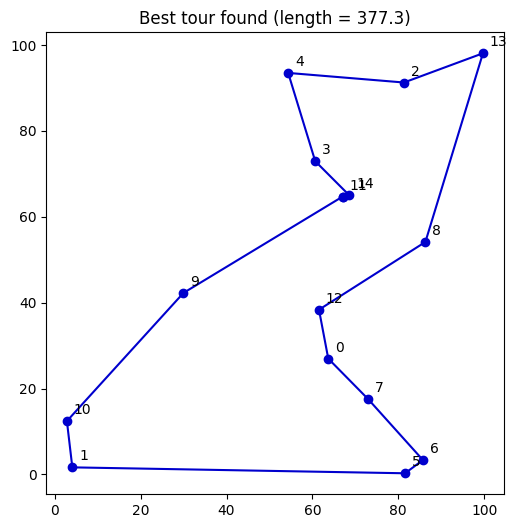

In [4]:
import matplotlib.pyplot as plt

tour = [int(i) for i in result.phenotype] + [int(result.phenotype[0])]
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(coords[tour, 0], coords[tour, 1], "o-", color="mediumblue")
for i, (x, y) in enumerate(coords):
    ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(5, 5))
ax.set_title(f"Best tour found (length = {result.fitness:.1f})")
ax.set_aspect("equal")
plt.show()

## A note on parameters

Both variants share `nAnts`, `maxiter`, `miniter`, `rho`, `maxage` and `minimize` /
`seed` from the base class; `rho` is unused by ACOR (kept only for a uniform constructor
signature) since ACOR's "pheromone update" is the archive replacement described above, not an
evaporation/deposit rule. There is no universally correct parameter set -- as with any
metaheuristic, expect to tune `nAnts`/`maxiter` against your evaluation budget, and the
exploration/exploitation knobs (`q`, `xi` for ACOR; `alpha`, `beta`, `rho` for Ant System)
against how rugged your search space is. Setting `seed` makes runs reproducible, which is
useful while tuning.

## Case study: GA vs. ACO on the TSP

The [genetic algorithm](bga.ipynb) guide mentions that ACOR and GA solve the same class of
box-constrained, real-valued problems. For the *combinatorial* side there's an analogous overlap:
`CombinatorialAntColonyOptimization` isn't the only way to attack the TSP with a metaheuristic from
this library -- {doc}`Building a Custom Genetic Algorithm <custom_ga>` shows how to write a
permutation-encoded `GeneticAlgorithm` subclass (order crossover + swap mutation) for exactly the
same problem. This section runs both on the *same* set of cities and compares them head to head, to
turn "neither is strictly better" into an actual number.

### The permutation GA, recapped

We reuse the `PermutationGeneticAlgorithm` built in {doc}`custom_ga`: `populate` seeds the first
generation with random permutations and breeds the rest via order crossover; `crossover` copies a
random slice from one parent and fills the rest from the other parent's order, guaranteeing a valid
tour; `mutate` swaps two random positions. Everything else (`select`, elitism, `seed`-based
reproducibility, champion tracking, `evolve`/`solve`) is inherited from
{py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm` unchanged -- see {doc}`custom_ga` for the
full derivation.

In [5]:
from sigmaepsilon.math.optimize.ga import GeneticAlgorithm


class PermutationGeneticAlgorithm(GeneticAlgorithm):
    __slots__ = ()

    def __init__(self, fnc, n_cities, **kwargs):
        placeholder_ranges = [[0, n_cities - 1]] * n_cities
        super().__init__(fnc, placeholder_ranges, **kwargs)

    def populate(self, genotypes=None):
        nPop = self.nPop
        if genotypes is None:
            genotypes = np.array(
                [self.rng.permutation(self.dim) for _ in range(int(nPop / 2))]
            )
        else:
            genotypes = np.asarray(genotypes, dtype=int)

        nParent = genotypes.shape[0]
        if nParent < nPop:
            offspring = []
            parent_pairs = self.random_parents_generator(genotypes)
            while (len(offspring) + nParent) < nPop:
                parent1, parent2 = next(parent_pairs)
                offspring.extend(self.crossover(parent1, parent2))
            genotypes = np.vstack([genotypes, offspring])
        return genotypes

    def crossover(self, parent1, parent2):
        n = self.dim
        if self.rng.random() > self.p_c:
            return parent1.copy(), parent2.copy()

        i, j = sorted(self.rng.choice(n, size=2, replace=False))

        def order_crossover(donor, filler):
            child = -np.ones(n, dtype=int)
            child[i:j] = donor[i:j]
            remaining = [city for city in filler if city not in child[i:j]]
            child[child == -1] = remaining
            return child

        child1 = order_crossover(parent1, parent2)
        child2 = order_crossover(parent2, parent1)
        return self.mutate(child1), self.mutate(child2)

    def mutate(self, child):
        if self.rng.random() < self.p_m:
            child = child.copy()
            i, j = self.rng.choice(self.dim, size=2, replace=False)
            child[i], child[j] = child[j], child[i]
        return child

### Running both on the same cities

We reuse the exact `coords` / `distance_matrix` / `tour_length` from the Combinatorial ACO example
above, and give both algorithms a comparable budget: `maxiter=150` (the hard cap), with each
algorithm free to stop earlier via its own stagnation rule (`maxage`). `nAnts=30` for the ant colony
and `nPop=60` for the GA are both in the same ballpark of "candidates constructed per generation".
We track the champion's fitness after every `evolve` call so we can plot the convergence curves
alongside the final tours.

In [ ]:
import time


def run_with_history(optimizer, maxiter):
    """Run `evolve` step by step, honoring the optimizer's own stopping criteria."""
    history = []
    for _ in range(maxiter):
        optimizer.evolve(1)
        optimizer.state.n_iter += 1
        history.append(optimizer.champion.fitness)
        min_iter_reached = optimizer.state.n_iter >= optimizer.miniter
        if optimizer.stopping_criteria() and min_iter_reached:
            break
    return history


aco_tsp = AntSystem(
    tour_length,
    distance_matrix,
    alpha=1.0,
    beta=3.0,
    rho=0.3,
    nAnts=30,
    maxiter=150,
    minimize=True,
    seed=0,
)
t0 = time.perf_counter()
aco_history = run_with_history(aco_tsp, 150)
aco_elapsed = time.perf_counter() - t0

ga_tsp = PermutationGeneticAlgorithm(
    tour_length, n_cities, nPop=60, minimize=True, maxage=30, seed=0
)
t0 = time.perf_counter()
ga_history = run_with_history(ga_tsp, 150)
ga_elapsed = time.perf_counter() - t0

print(f"ACO: length={aco_tsp.champion.fitness:.1f}  n_iter={aco_tsp.state.n_iter}  n_fev={aco_tsp.state.n_fev}  time={aco_elapsed:.4f}s")
print(f"GA:  length={ga_tsp.champion.fitness:.1f}  n_iter={ga_tsp.state.n_iter}  n_fev={ga_tsp.state.n_fev}  time={ga_elapsed:.4f}s")

On this 15-city instance, ACO both finds a *shorter* tour and does so with roughly an order of
magnitude fewer function evaluations: it converges (and hits its `maxage=10` stagnation limit) after
21 iterations x 30 ants = 630 evaluations, while the GA runs for 86 generations x 60 individuals =
5160 evaluations before its own `maxage=30` triggers -- and still lands on a longer tour. The wall-clock
times for this single run (`aco_elapsed` / `ga_elapsed` above) are similar despite the very different
evaluation counts, since `tour_length` is cheap here and per-evaluation Python overhead dominates; the
10-seed comparison below measures this more carefully. Let's look at the convergence curves and the
resulting tours side by side.

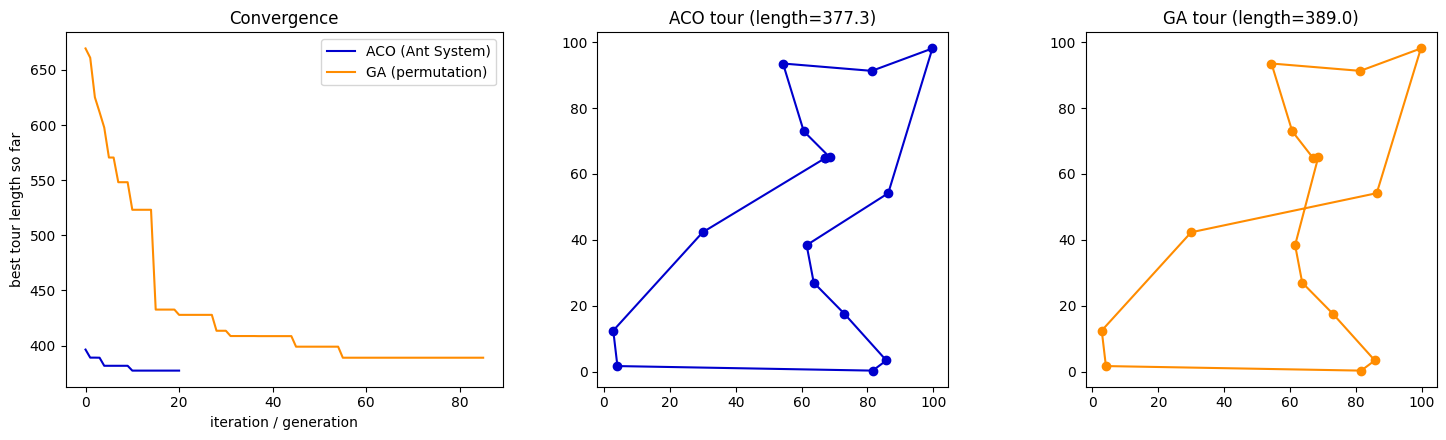

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(aco_history, label="ACO (Ant System)", color="mediumblue")
axes[0].plot(ga_history, label="GA (permutation)", color="darkorange")
axes[0].set_xlabel("iteration / generation")
axes[0].set_ylabel("best tour length so far")
axes[0].set_title("Convergence")
axes[0].legend()

aco_tour = [int(i) for i in aco_tsp.champion.phenotype] + [int(aco_tsp.champion.phenotype[0])]
axes[1].plot(coords[aco_tour, 0], coords[aco_tour, 1], "o-", color="mediumblue")
axes[1].set_title(f"ACO tour (length={aco_tsp.champion.fitness:.1f})")
axes[1].set_aspect("equal")

ga_tour = [int(i) for i in ga_tsp.champion.phenotype] + [int(ga_tsp.champion.phenotype[0])]
axes[2].plot(coords[ga_tour, 0], coords[ga_tour, 1], "o-", color="darkorange")
axes[2].set_title(f"GA tour (length={ga_tsp.champion.fitness:.1f})")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

### Is seed 0 a fluke? Robustness over multiple runs

A single seed can always be flattering to one side or the other. Let's repeat the exact same
comparison for 10 different seeds and look at the spread of the results, not just their mean.

In [8]:
aco_lengths, ga_lengths = [], []
aco_times, ga_times = [], []
aco_fevs, ga_fevs = [], []

for seed in range(10):
    a = AntSystem(
        tour_length, distance_matrix, alpha=1.0, beta=3.0, rho=0.3,
        nAnts=30, maxiter=150, minimize=True, seed=seed,
    )
    t0 = time.perf_counter()
    run_with_history(a, 150)
    aco_times.append(time.perf_counter() - t0)
    aco_lengths.append(a.champion.fitness)
    aco_fevs.append(a.state.n_fev)

    g = PermutationGeneticAlgorithm(tour_length, n_cities, nPop=60, minimize=True, maxage=30, seed=seed)
    t0 = time.perf_counter()
    run_with_history(g, 150)
    ga_times.append(time.perf_counter() - t0)
    ga_lengths.append(g.champion.fitness)
    ga_fevs.append(g.state.n_fev)

print(f"{'':4}{'mean':>10}{'std':>10}{'min':>10}{'max':>10}{'mean n_fev':>12}{'mean time [s]':>15}")
print(f"{'ACO':4}{np.mean(aco_lengths):10.2f}{np.std(aco_lengths):10.2f}{np.min(aco_lengths):10.2f}{np.max(aco_lengths):10.2f}{np.mean(aco_fevs):12.0f}{np.mean(aco_times):15.4f}")
print(f"{'GA':4}{np.mean(ga_lengths):10.2f}{np.std(ga_lengths):10.2f}{np.min(ga_lengths):10.2f}{np.max(ga_lengths):10.2f}{np.mean(ga_fevs):12.0f}{np.mean(ga_times):15.4f}")

          mean       std       min       max  mean n_fev  mean time [s]
ACO     377.38      0.21    377.31    378.01         648         0.1505
GA      402.12     17.86    386.98    448.84        5070         0.1531


Across 10 seeds, ACO isn't just better on average -- it's dramatically more *consistent*: a
standard deviation of about 0.2 vs. the GA's ~18, on a mean tour length that is itself noticeably
shorter (~377 vs. ~402). Wall-clock time per run is comparable for both (a few tenths of a second on
this problem size), so ACO's advantage in evaluation count doesn't translate into much of a wall-time
win here -- the per-evaluation Python overhead dominates at this scale. What *does* scale is the
evaluation *count*: ACO needing ~650 evaluations against the GA's ~5000 to reach a better answer
matters a great deal once `tour_length` is expensive (e.g. a real routing cost function instead of a
Euclidean distance sum).

### Final verdict

For this particular problem shape -- a symmetric-distance-matrix TSP -- `CombinatorialAntColonyOptimization`
is the better default, and the gap is not marginal:

* **Solution quality**: consistently shorter tours across seeds, not just a lower mean.
* **Consistency**: an order of magnitude lower run-to-run variance, which matters if you only get to
  run the optimizer once (e.g. inside a larger pipeline) rather than take the best of many restarts.
* **Sample efficiency**: roughly 8x fewer objective evaluations to reach a better answer -- decisive
  once the objective itself is expensive.
* **Effort**: zero custom code. `CombinatorialAntColonyOptimization` is used directly out of the box,
  whereas the GA route requires writing and validating a permutation-aware `populate`/`crossover`/
  `mutate` (as {doc}`custom_ga` walks through) before it can be applied at all.

This isn't a verdict against the GA framework in general -- {py:class}`~sigmaepsilon.math.optimize.ga.GeneticAlgorithm`'s
pluggability (custom selection strategies, elitism, arbitrary genotype representations) is exactly
what made a permutation GA possible here in the first place, and for problems that don't map onto a
pairwise-cost/pheromone structure (or that need crossover-driven recombination of unrelated partial
solutions, e.g. bin-packing-like problems with block structure), a custom GA may well be the only
metaheuristic option in this library, ACOR included. But *for the TSP specifically*, ACO's pheromone
mechanism is a much closer structural match to the problem than a permutation genotype bent into
shape with order crossover -- and the numbers above bear that out. If you're choosing a metaheuristic
for a new routing/sequencing problem in this library, start with
{py:class}`~sigmaepsilon.math.optimize.aco.CombinatorialAntColonyOptimization` and only reach for a
custom GA if ACO's pheromone-matrix representation genuinely doesn't fit your problem's structure.